In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import random

In [ ]:
def f(x):
  return 4*x**2 -2*x +8

In [ ]:
f(6)

140

In [ ]:
xs = np.arange(-6, 6, 0.25)
ys = f(xs)
print(ys)

[164.   151.75 140.   128.75 118.   107.75  98.    88.75  80.    71.75
  64.    56.75  50.    43.75  38.    32.75  28.    23.75  20.    16.75
  14.    11.75  10.     8.75   8.     7.75   8.     8.75  10.    11.75
  14.    16.75  20.    23.75  28.    32.75  38.    43.75  50.    56.75
  64.    71.75  80.    88.75  98.   107.75 118.   128.75]


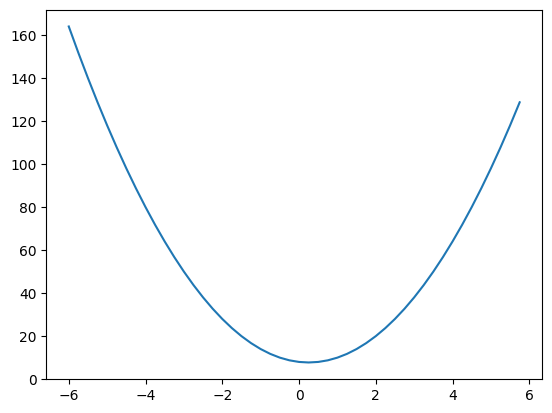

In [ ]:
plt.plot(xs, ys)

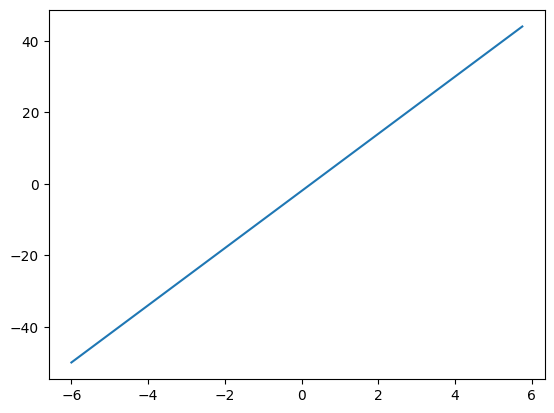

In [ ]:
h = 0.00000000001
yh = f(xs+h)
dy = (yh - ys)/h
plt.plot(xs, dy)

**Single Neuron**

In [63]:
class Value():
  def __init__(self, data, _children = (), _op = '', label = '') -> None:
    self.data = data
    self.prev =  set(_children)
    self.op = _op
    self.label = label
    self.grad = 0.0
    self._backward = lambda: None

  def __repr__(self) -> str:
    return f"Value ( data = {self.data})"

  def __add__ (self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward  = _backward
    return out

  def __mul__ (self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self , other), '*')
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def __rmul__(self, other): # other * self
        return self * other

  def tanh (self):
    x  =  self.data
    t = (math.exp(2*x) -1)/(math.exp(2*x) + 1)
    out = Value(t , (self , ), 'tanh')
    def _backward():
     self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out

  def __neg__(self): # -self
        return self * -1

  def __radd__(self, other): # other + self
        return self + other

  def __sub__(self, other): # self - other
        return self + (-other)

  def __rsub__(self, other): # other - self
        return other + (-self)
  def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

  def backword(self):
    topo = []
    visited = set ()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v.prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [3]:
a = Value(3.3)
b = Value(-2)
c = Value(.1)
d = a*b + c
e = d.tanh()
e

Value ( data = -0.9999954793514042)

In [4]:
print(e.grad, d.grad, c.grad, b.grad, a.grad)

0.0 0.0 0.0 0.0 0.0


In [5]:
e.backword()

In [6]:
print(e.grad, d.grad, c.grad, b.grad, a.grad)

1.0 9.041276755383798e-06 9.041276755383798e-06 2.9836213292766533e-05 -1.8082553510767596e-05


**One Layer of neuron**

In [64]:
class Neuron:

  def __init__(self, nin) -> None:
    self.w = [Value(random.uniform(-1, 1)) for _ in range(nin) ]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    act = sum((wi *xi for wi , xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
        return self.w + [self.b]

class Layer:

  def __init__(self, nin , nout) -> None:
    self.neuron = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    out = [n(x) for n in self.neuron]
    return out[0] if len(out) == 1 else out

  def parameters(self):
        return [p for n in self.neuron for p in n.parameters()]

class MLP():

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [76]:
x = [3.2, 2.3, 4]
n = MLP(3, [4, 4,1])
n(x)

Value ( data = -0.6980661816746753)

**Furmula of calculation no of parameters for a fully connect NN**

neuron wise
pn = len(x)+1

layer wise
pl =  pn * nn

we are doing dot product in x*w



In [56]:
len(n.parameters())

41

In [71]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [77]:
for k in range(40):
  # forward pass
  yp = [n(x) for x in xs]
  loss = sum((yst - ypt)**2 for yst ,ypt in zip(ys,  yp))
  # backward pass
  for p in n.parameters():
    # we are making it zero because they accumulate in adding from several passes
    p.grad = 0.0
  loss.backword()
  # update
  for p in n.parameters():
    p.data += -0.05 * p.grad
  print(k, loss)

0 Value ( data = 4.782268757172031)
1 Value ( data = 1.0243454054645145)
2 Value ( data = 0.6527568079196415)
3 Value ( data = 0.40291785612045167)
4 Value ( data = 0.3156913500559134)
5 Value ( data = 0.2596264776038713)
6 Value ( data = 0.2191160708800292)
7 Value ( data = 0.18867281104894662)
8 Value ( data = 0.16507072928134314)
9 Value ( data = 0.14630438298440895)
10 Value ( data = 0.1310687329464154)
11 Value ( data = 0.11848159919201248)
12 Value ( data = 0.1079272144308897)
13 Value ( data = 0.09896384929783342)
14 Value ( data = 0.09126705990694273)
15 Value ( data = 0.08459360376512096)
16 Value ( data = 0.07875780036511199)
17 Value ( data = 0.07361563204758644)
18 Value ( data = 0.069053798968274)
19 Value ( data = 0.06498202661175002)
20 Value ( data = 0.0613275578415782)
21 Value ( data = 0.05803114247820144)
22 Value ( data = 0.05504407259499403)
23 Value ( data = 0.05232596038784457)
24 Value ( data = 0.049843051479744334)
25 Value ( data = 0.04756692974596839)
26 Valu